# MTFL_custom_12_2 Feature 기반 Grad-CAM + Anomaly Score

`MTFL_custom_12_2/features`의 L64/L32/L8 txt feature로 anomaly score를 계산하고, score가 가장 높은 segment 주변의 동영상 clip만 VST에 다시 넣어 Grad-CAM을 시각화합니다. 전체 영상을 메모리에 올리지 않습니다.

In [ ]:
import os
import sys
import gc
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

PROJECT_ROOT = r"C:\\4_1_딥러닝_팀플"
MTFL_ROOT = os.path.join(PROJECT_ROOT, "MTFL")
DETECTION_ROOT = os.path.join(MTFL_ROOT, "detection")
UTILS_ROOT = os.path.join(MTFL_ROOT, "utils")

sys.path.insert(0, DETECTION_ROOT)
sys.path.insert(0, UTILS_ROOT)
os.chdir(MTFL_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA GeForce RTX 3070


In [ ]:
CUSTOM_ROOT = r"C:\\4_1_딥러닝_팀플\\MTFL_custom_12_2"
VIDEO_ROOT = os.path.join(CUSTOM_ROOT, "videos")
FEATURE_ROOT = os.path.join(CUSTOM_ROOT, "features")
TEST_ANNO = os.path.join(CUSTOM_ROOT, "annotations", "test_anno.txt")

# 이 detection checkpoint를 사용해 custom_12_2 feature에 score를 냅니다.
MTFL_CKPT = r"C:\\4_1_딥러닝_팀플\\MTFL_UCF_custom\\checkpoints_common\\MTFL-1480.pkl"
VST_CKPT = r"C:\\4_1_딥러닝_팀플\\MTFL_custom\\swin_base_patch244_window877_kinetics400_22k.pth"

CAM_BRANCH = "s"       # "s"=L8, "m"=L32, "l"=L64. L8이 가장 가볍습니다.
CLIP_LEN_FOR_CAM = 8
RESIZE = 224
SEG_NUM = 32
VIDEO_INDEX = 0        # test_anno 안의 몇 번째 영상을 볼지

print("video root:", os.path.exists(VIDEO_ROOT))
print("feature root:", os.path.exists(FEATURE_ROOT))
print("test anno:", os.path.exists(TEST_ANNO))
print("mtfl ckpt:", os.path.exists(MTFL_CKPT))
print("vst ckpt:", os.path.exists(VST_CKPT))

video root: True
feature root: True
test anno: True
mtfl ckpt: True
vst ckpt: True


In [ ]:
from model import Model as MTFLModel
from feature_extractor import load_VST

def read_features(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append([float(x) for x in line.strip().split()])
    return torch.tensor(rows, dtype=torch.float32)

def load_feature_triplet(rel_video):
    stem = os.path.splitext(rel_video.replace("/", os.sep))[0]
    lf_path = os.path.join(FEATURE_ROOT, "L64", stem + ".txt")
    mf_path = os.path.join(FEATURE_ROOT, "L32", stem + ".txt")
    sf_path = os.path.join(FEATURE_ROOT, "L8", stem + ".txt")
    print("L64:", lf_path)
    print("L32:", mf_path)
    print("L8 :", sf_path)
    return read_features(lf_path), read_features(mf_path), read_features(sf_path)

def parse_anno(anno_path):
    items = []
    with open(anno_path, "r", encoding="utf-8") as f:
        for line in f.read().splitlines():
            if not line.strip():
                continue
            parts = line.split()
            rel_video = parts[0]
            cls_name = parts[1]
            num_frames = int(parts[2]) if len(parts) >= 3 else None
            intervals = [int(x) for x in parts[3:]]
            items.append({
                "rel_video": rel_video,
                "cls_name": cls_name,
                "num_frames": num_frames,
                "intervals": intervals,
            })
    return items

items = parse_anno(TEST_ANNO)
item = items[VIDEO_INDEX]
rel_video = item["rel_video"]
video_path = os.path.join(VIDEO_ROOT, rel_video.replace("/", os.sep))

print("selected:", item)
print("video:", video_path)
print("video exists:", os.path.exists(video_path))

apex is not installed
selected: {'rel_video': 'assault/12-1_cam01_assault01_place09_day_spring.mp4', 'cls_name': '1', 'num_frames': 9135, 'intervals': [5349, 8985]}
video: C:\\4_1_딥러닝_팀플\\MTFL_custom_12_2\videos\assault\12-1_cam01_assault01_place09_day_spring.mp4
video exists: True


c:\Users\dongwon\anaconda3\envs\mtfl_swin\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
mtfl = MTFLModel(feature_dim=1024, batch_size=1, seg_num=SEG_NUM).to(device).eval()
mtfl.load_state_dict(torch.load(MTFL_CKPT, map_location=device))
for p in mtfl.parameters():
    p.requires_grad_(False)

vst = load_VST(VST_CKPT, device).eval()
for p in vst.parameters():
    p.requires_grad_(False)

print("MTFL checkpoint and VST ready")

c:\Users\dongwon\anaconda3\envs\mtfl_swin\lib\site-packages\torch\functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ..\aten\src\ATen\native\TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


load checkpoint from local path: C:\\4_1_딥러닝_팀플\\MTFL_custom\\swin_base_patch244_window877_kinetics400_22k.pth
The model and loaded state dict do not match exactly

size mismatch for cls_head.fc_cls.weight: copying a param with shape torch.Size([400, 1024]) from checkpoint, the shape in current model is torch.Size([18, 1024]).
size mismatch for cls_head.fc_cls.bias: copying a param with shape torch.Size([400]) from checkpoint, the shape in current model is torch.Size([18]).
MTFL checkpoint and VST ready


In [ ]:
# MTFL_custom_12_2/features의 L64/L32/L8 txt feature를 사용해 score 계산
lf, mf, sf = load_feature_triplet(rel_video)

input_l = lf.unsqueeze(0).to(device)
input_m = mf.unsqueeze(0).to(device)
input_s = sf.unsqueeze(0).to(device)

with torch.no_grad():
    _, _, _, _, txt_scores = mtfl(input_l, input_m, input_s)

score_vec = txt_scores.squeeze(0).squeeze(-1).detach().cpu().numpy()
target_segment = int(np.argmax(score_vec))

num_frames = item["num_frames"]
seg_start = int(target_segment * num_frames / SEG_NUM) if num_frames else None
seg_end = int((target_segment + 1) * num_frames / SEG_NUM) if num_frames else None

print("target segment:", target_segment)
print("target score:", float(score_vec[target_segment]))
print("target frame range:", seg_start, "~", seg_end)

L64: C:\\4_1_딥러닝_팀플\\MTFL_custom_12_2\features\L64\assault\12-1_cam01_assault01_place09_day_spring.txt
L32: C:\\4_1_딥러닝_팀플\\MTFL_custom_12_2\features\L32\assault\12-1_cam01_assault01_place09_day_spring.txt
L8 : C:\\4_1_딥러닝_팀플\\MTFL_custom_12_2\features\L8\assault\12-1_cam01_assault01_place09_day_spring.txt
target segment: 26
target score: 0.09920348972082138
target frame range: 7422 ~ 7707


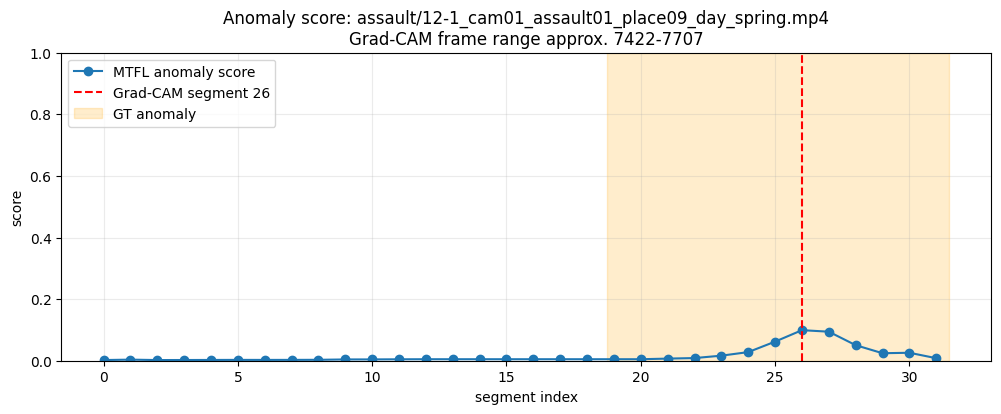

In [ ]:
# Anomaly score graph: 어떤 segment/프레임을 시각화했는지 함께 표시합니다.
x = np.arange(len(score_vec))
plt.figure(figsize=(12, 4))
plt.plot(x, score_vec, marker="o", linewidth=1.5, label="MTFL anomaly score")
plt.axvline(target_segment, color="red", linestyle="--", label=f"Grad-CAM segment {target_segment}")

if item["num_frames"] and item["intervals"]:
    for i in range(0, len(item["intervals"]) - 1, 2):
        s, e = item["intervals"][i], item["intervals"][i + 1]
        if s != -1 and e != -1:
            seg_s = s / item["num_frames"] * SEG_NUM
            seg_e = e / item["num_frames"] * SEG_NUM
            plt.axvspan(seg_s, seg_e, color="orange", alpha=0.2, label="GT anomaly" if i == 0 else None)

plt.title(f"Anomaly score: {rel_video}\nGrad-CAM frame range approx. {seg_start}-{seg_end}")
plt.xlabel("segment index")
plt.ylabel("score")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [ ]:
MEAN = torch.tensor([0.400, 0.388, 0.372]).view(3, 1, 1, 1)
STD = torch.tensor([0.247, 0.245, 0.243]).view(3, 1, 1, 1)

def read_clip_by_frame_range(video_path, center_frame, clip_len=8, resize=224):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if total <= 0:
        total = center_frame + clip_len
    start = max(0, int(center_frame) - clip_len // 2)
    end = min(total, start + clip_len)
    start = max(0, end - clip_len)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    frames = []
    for _ in range(clip_len):
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (resize, resize))
        frames.append(frame)
    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"Cannot read frames around {center_frame}: {video_path}")
    while len(frames) < clip_len:
        frames.append(frames[-1].copy())

    arr = np.stack(frames)
    tensor = torch.from_numpy(arr).float() / 255.0
    tensor = tensor.permute(0, 3, 1, 2)  # [T,C,H,W]
    clip = tensor.permute(1, 0, 2, 3)    # [C,T,H,W]
    clip = (clip - MEAN) / STD
    return clip.unsqueeze(0), tensor, start, end, total, fps

center_frame = (seg_start + seg_end) // 2
live_clip, display_frames, clip_start, clip_end, video_total_frames, video_fps = read_clip_by_frame_range(
    video_path,
    center_frame=center_frame,
    clip_len=CLIP_LEN_FOR_CAM,
    resize=RESIZE,
)
live_clip = live_clip.to(device).requires_grad_(True)

print("video total frames:", video_total_frames, "fps:", video_fps)
print("Grad-CAM clip frames:", clip_start, "~", clip_end)
print("live clip:", tuple(live_clip.shape))

video total frames: 9126 fps: 29.97002997002997
Grad-CAM clip frames: 7560 ~ 7568
live clip: (1, 3, 8, 224, 224)


In [ ]:
class VSTGradCAMHook:
    def __init__(self, layer):
        self.activation = None
        self.gradient = None
        self.h1 = layer.register_forward_hook(self.forward_hook)
        self.h2 = layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inputs, output):
        self.activation = output[0] if isinstance(output, tuple) else output

    def backward_hook(self, module, grad_input, grad_output):
        grad = grad_output[0]
        self.gradient = grad[0] if isinstance(grad, tuple) else grad

def replace_segment_feature(base_feature, segment_idx, new_feature):
    return torch.cat([
        base_feature[:segment_idx],
        new_feature.unsqueeze(0),
        base_feature[segment_idx + 1:],
    ], dim=0)

def live_vst_feature(clip):
    feat = vst.extract_feat(clip)
    feat = feat.mean(dim=[2, 3, 4])
    return feat.squeeze(0)

hook = VSTGradCAMHook(vst.backbone.layers[-1])
mtfl.zero_grad(set_to_none=True)
vst.zero_grad(set_to_none=True)

base_l = lf.to(device).detach().clone()
base_m = mf.to(device).detach().clone()
base_s = sf.to(device).detach().clone()

live_feat = live_vst_feature(live_clip)

if CAM_BRANCH == "l":
    branch = replace_segment_feature(base_l, target_segment, live_feat)
    input_l2, input_m2, input_s2 = branch.unsqueeze(0), base_m.unsqueeze(0), base_s.unsqueeze(0)
elif CAM_BRANCH == "m":
    branch = replace_segment_feature(base_m, target_segment, live_feat)
    input_l2, input_m2, input_s2 = base_l.unsqueeze(0), branch.unsqueeze(0), base_s.unsqueeze(0)
else:
    branch = replace_segment_feature(base_s, target_segment, live_feat)
    input_l2, input_m2, input_s2 = base_l.unsqueeze(0), base_m.unsqueeze(0), branch.unsqueeze(0)

_, _, _, _, scores = mtfl(input_l2, input_m2, input_s2)
target_score = scores[:, target_segment, :].mean()
print("target_score requires_grad:", target_score.requires_grad)
target_score.backward()

act = hook.activation
grad = hook.gradient
print("target score:", float(target_score.detach().cpu()))
print("activation:", tuple(act.shape), "gradient:", tuple(grad.shape))

target_score requires_grad: True
target score: 0.06948164850473404
activation: (1, 1024, 4, 7, 7) gradient: (1, 1024, 4, 7, 7)


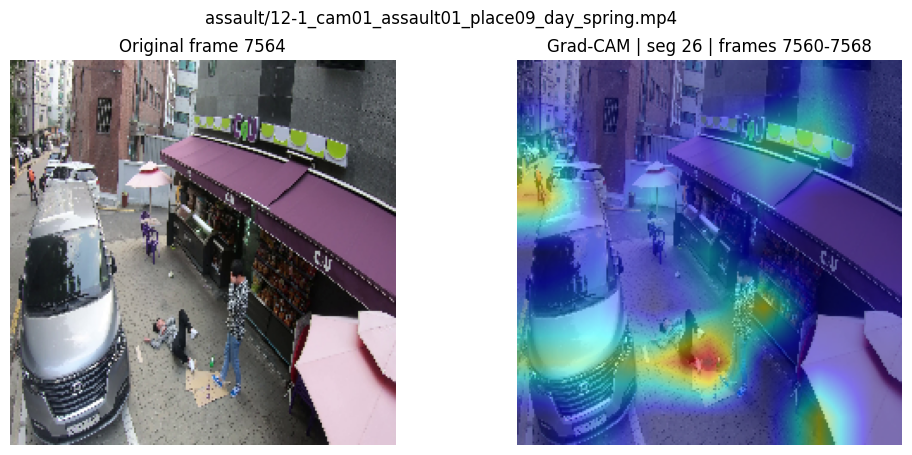

시각화한 segment: 26
시각화한 frame range: 7560 ~ 7568
해당 segment score: 0.09920348972082138


In [ ]:
weights = grad.mean(dim=[2, 3, 4], keepdim=True)
cam = torch.relu((weights * act).sum(dim=1))
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-6)
cam_np = cam[0].detach().cpu().numpy()
cam_2d = cam_np[cam_np.shape[0] // 2] if cam_np.ndim == 3 else cam_np

mid_idx = display_frames.size(0) // 2
frame = display_frames[mid_idx].detach().cpu().numpy().transpose(1, 2, 0)
frame = np.uint8(np.clip(frame * 255, 0, 255))
frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

cam_2d = cv2.resize(cam_2d, (frame_bgr.shape[1], frame_bgr.shape[0]))
heatmap = np.uint8(255 * cam_2d)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(frame_bgr, 0.55, heatmap, 0.45, 0)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(frame)
axes[0].set_title(f"Original frame {clip_start + mid_idx}")
axes[0].axis("off")
axes[1].imshow(overlay_rgb)
axes[1].set_title(f"Grad-CAM | seg {target_segment} | frames {clip_start}-{clip_end}")
axes[1].axis("off")
plt.suptitle(rel_video)
plt.show()

print("시각화한 segment:", target_segment)
print("시각화한 frame range:", clip_start, "~", clip_end)
print("해당 segment score:", float(score_vec[target_segment]))

video: assault/12-1_cam01_assault01_place09_day_spring.mp4
num_frames: 9135
gt intervals: [5349, 8985]


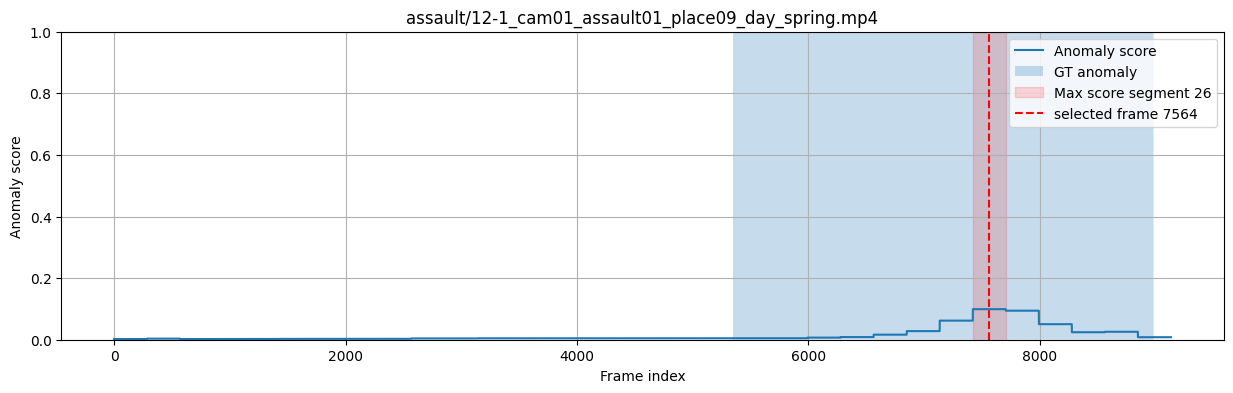

max score segment: 26
max score: 0.09920349
selected frame range: 7422 ~ 7707
selected center frame: 7564


In [ ]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = r"C:\4_1_딥러닝_팀플"
MTFL_ROOT = os.path.join(PROJECT_ROOT, "MTFL")
DETECTION_ROOT = os.path.join(MTFL_ROOT, "detection")

sys.path.insert(0, DETECTION_ROOT)

from model import Model as MTFLModel

CUSTOM_ROOT = r"C:\4_1_딥러닝_팀플\MTFL_custom_12_2"
FEATURE_ROOT = os.path.join(CUSTOM_ROOT, "features")
TEST_ANNO = os.path.join(CUSTOM_ROOT, "annotations", "test_anno.txt")

MTFL_CKPT = r"C:\4_1_딥러닝_팀플\MTFL_UCF_custom\checkpoints_common\MTFL-1480.pkl"

SEG_NUM = 32
VIDEO_INDEX = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def read_features(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append([float(x) for x in line.strip().split()])
    return torch.tensor(rows, dtype=torch.float32)


def parse_anno(anno_path):
    items = []
    with open(anno_path, "r", encoding="utf-8") as f:
        for line in f.read().splitlines():
            if not line.strip():
                continue

            parts = line.split()
            items.append({
                "rel_video": parts[0],
                "cls_name": parts[1],
                "num_frames": int(parts[2]),
                "intervals": [int(x) for x in parts[3:]],
            })
    return items


def load_feature_triplet(rel_video):
    stem = os.path.splitext(rel_video.replace("/", os.sep))[0]

    lf = read_features(os.path.join(FEATURE_ROOT, "L64", stem + ".txt"))
    mf = read_features(os.path.join(FEATURE_ROOT, "L32", stem + ".txt"))
    sf = read_features(os.path.join(FEATURE_ROOT, "L8", stem + ".txt"))

    return lf, mf, sf


items = parse_anno(TEST_ANNO)
item = items[VIDEO_INDEX]

rel_video = item["rel_video"]
num_frames = item["num_frames"]
intervals = item["intervals"]

print("video:", rel_video)
print("num_frames:", num_frames)
print("gt intervals:", intervals)

lf, mf, sf = load_feature_triplet(rel_video)

mtfl = MTFLModel(feature_dim=1024, batch_size=1, seg_num=SEG_NUM).to(device).eval()
mtfl.load_state_dict(torch.load(MTFL_CKPT, map_location=device))

with torch.no_grad():
    _, _, _, _, scores = mtfl(
        lf.unsqueeze(0).to(device),
        mf.unsqueeze(0).to(device),
        sf.unsqueeze(0).to(device),
    )

segment_scores = scores.squeeze(0).squeeze(-1).detach().cpu().numpy()

frame_scores = np.zeros(num_frames, dtype=np.float32)
for seg_idx, score in enumerate(segment_scores):
    start = int(seg_idx * num_frames / SEG_NUM)
    end = int((seg_idx + 1) * num_frames / SEG_NUM)
    frame_scores[start:end] = score

gt = np.zeros(num_frames, dtype=np.float32)
for i in range(0, len(intervals) - 1, 2):
    start, end = intervals[i], intervals[i + 1]
    if start != -1 and end != -1:
        gt[max(0, start):min(num_frames, end)] = 1.0

target_segment = int(np.argmax(segment_scores))
target_frame_start = int(target_segment * num_frames / SEG_NUM)
target_frame_end = int((target_segment + 1) * num_frames / SEG_NUM)
target_frame = (target_frame_start + target_frame_end) // 2

plt.figure(figsize=(15, 4))
plt.plot(frame_scores, label="Anomaly score")

if np.any(gt == 1):
    plt.fill_between(
        np.arange(len(gt)),
        0,
        1,
        where=(gt == 1),
        alpha=0.25,
        label="GT anomaly",
    )

plt.axvspan(
    target_frame_start,
    target_frame_end,
    color="red",
    alpha=0.15,
    label=f"Max score segment {target_segment}",
)

plt.axvline(
    target_frame,
    color="red",
    linestyle="--",
    label=f"selected frame {target_frame}",
)

plt.ylim(0, 1)
plt.title(rel_video)
plt.xlabel("Frame index")
plt.ylabel("Anomaly score")
plt.grid(True)
plt.legend()
plt.show()

print("max score segment:", target_segment)
print("max score:", segment_scores[target_segment])
print("selected frame range:", target_frame_start, "~", target_frame_end)
print("selected center frame:", target_frame)